# 04 — Corridor Analysis: Buffering, Clipping, and Exceedance Detection

## What this notebook does

Applies the corridor analysis to the CHM from Notebook 03:

1. Load the CA transmission line centerline
2. Buffer by corridor width (default: 15m / 50ft)
3. Clip the CHM to the corridor buffer
4. Flag pixels exceeding the vegetation height threshold
5. Export all three final output artifacts

---

## Inputs

- `data/raw/<corridor_centerline>.shp` — CA transmission line centerline (CA Energy Commission GIS)
- `data/processed/chm.tif` — full-extent CHM from Notebook 03
- Both must be in EPSG:32611 before any spatial operation

## Outputs

- `outputs/rasters/chm_clipped.tif`
- `outputs/vector/flagged_trees.gpkg` — exceedance polygons with `height_m` attribute
- `outputs/tables/flagged_tree_summary.csv` — count and mean height by corridor segment

## Functions called

- `src.corridor.load_corridor_centerline(filepath)`
- `src.corridor.buffer_corridor(gdf, buffer_distance_m=15)`
- `src.corridor.clip_chm_to_corridor(chm_path, corridor_gdf, output_path)`
- `src.corridor.threshold_exceedance(chm_clipped_path, height_threshold_m=4.57)`

---

## What to confirm before calling the project complete

- All three output files exist and are non-empty
- Flagged tree polygons fall within the corridor buffer (spatial sanity check)
- Run accuracy assessment in `validation/accuracy_assessment.py` — required before results are defensible


In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path
import geopandas as gpd
from shapely.geometry import shape

ROOT = Path.cwd().parent  # assumes notebook is in notebooks/
sys.path.append(str(ROOT))
from src.corridor import load_corridor_centerline, buffer_corridor, clip_chm_to_corridor, threshold_exceedance


normalized_las_path = ROOT / "data" / "processed" / "socal_sespe_32611_normalized.laz"
chm_path = ROOT / "outputs" / "rasters" / "socal_sespe_32611_chm.tif"
clipped_chm_path = ROOT / "outputs" / "rasters" / "socal_sespe_32611_chm_clipped.tif"
exceedence_raster_path = ROOT / "outputs" / "rasters" / "socal_sespe_32611_exceedance.tif"


In [2]:

url = (
    "https://services3.arcgis.com/bWPjFyq029ChCGur/arcgis/rest/services"
    "/Transmission_Line/FeatureServer/2/query"
    "?outFields=*&where=1%3D1&f=geojson"
)

In [3]:
clipped_transmission_lines = load_corridor_centerline(url, normalized_las_path)


In [4]:
lines_with_buffer = buffer_corridor(clipped_transmission_lines, buffer_distance_m=15)

In [5]:
clip_chm_to_corridor(
    chm_path=chm_path,
    corridor_gdf=lines_with_buffer,
    output_path=clipped_chm_path,
)

In [6]:
threshold_df = threshold_exceedance(
    chm_clipped_path=clipped_chm_path,
    height_threshold_m=4.57  # example threshold in meters, 4.57m (15ft)
)

/Users/ianmorris/anaconda3/envs/lidar-corridor/lib/python3.11/site-packages/rasterio/features.py:129: RuntimeWarning: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
  yield from _shapes(source, mask, connectivity, transform)


In [7]:
threshold_df

,geometry,height_m
0,"POLYGON ((322468.35 3810737.84, 322468.35 3810...",5.690000
1,"POLYGON ((322454.35 3810734.84, 322454.35 3810...",6.180000
2,"POLYGON ((322442.35 3810734.84, 322442.35 3810...",5.495000
3,"POLYGON ((322472.35 3810732.84, 322472.35 3810...",28.392500
4,"POLYGON ((322451.35 3810735.84, 322451.35 3810...",5.447143
...,...,...
1542,"POLYGON ((320774.35 3810413.84, 320774.35 3810...",6.730000
1543,"POLYGON ((320761.35 3810412.84, 320761.35 3810...",6.590000
1544,"POLYGON ((320760.35 3810410.84, 320760.35 3810...",7.050000
1545,"POLYGON ((320779.35 3810407.84, 320779.35 3810...",12.600000


<Axes: >

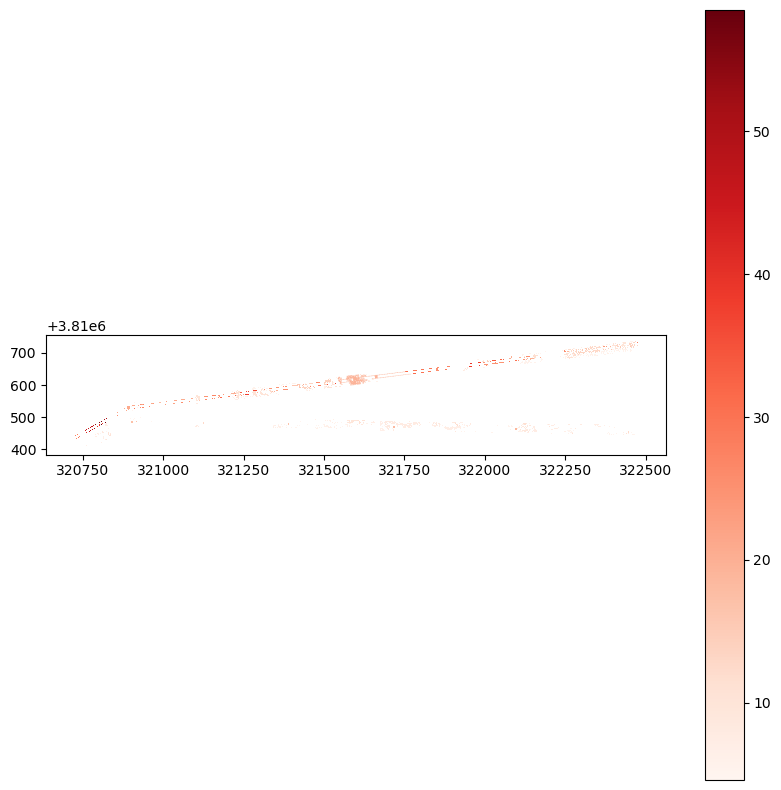

In [8]:
# visualize the treshold exceedance
fig, ax = plt.subplots(figsize=(10, 10))                                                            
threshold_df.plot(column="height_m", cmap="Reds", legend=True, ax=ax)

In [9]:
with rasterio.open(clipped_chm_path) as chm_clipped_src:
    chm_data = chm_clipped_src.read(1)  # Read the first (and only) band
    chm_meta = chm_clipped_src.meta  # Get metadata for later use

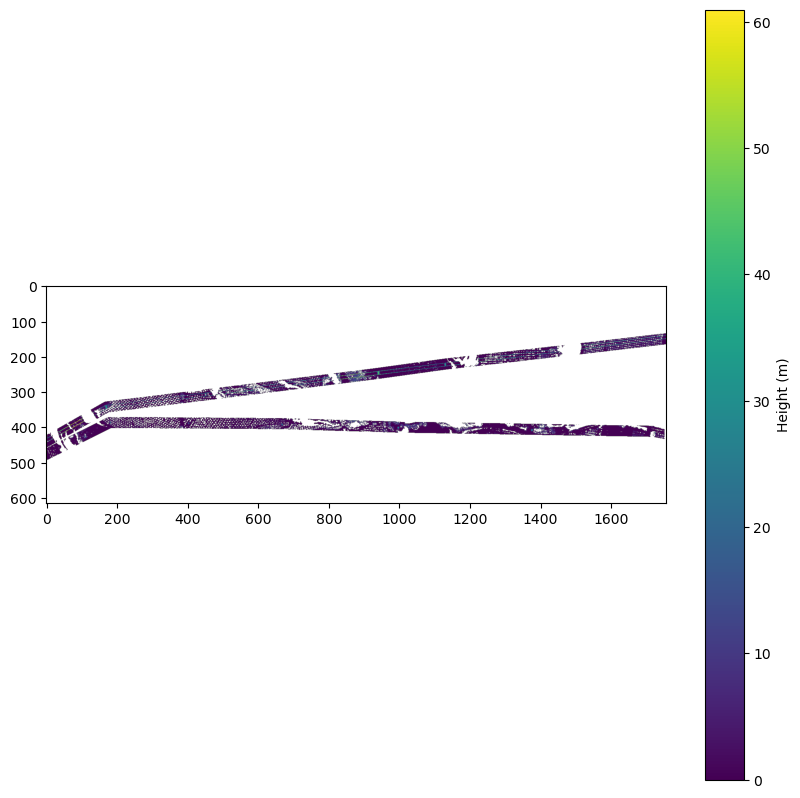

In [10]:
# visualize the CHM
plt.figure(figsize=(10, 10))
plt.imshow(chm_data, cmap="viridis")
plt.colorbar(label="Height (m)") 

From Notebook 04, save:
- `outputs/vector/flagged_trees.gpkg`
- `outputs/tables/flagged_tree_summary.csv` (count and mean height by corridor segment)

In [11]:
# output vector data
threshold_df.to_file(ROOT / "outputs" / "vector" / "flagged_trees.gpkg", driver="GPKG")

# summary: overall count and mean height across all exceedance polygons
summary_df = threshold_df[["height_m"]].agg(
    count_exceedance_polygons=("height_m", "count"),
    mean_exceedance_height=("height_m", "mean")
)
summary_df.to_csv(ROOT / "outputs" / "tables" / "flagged_trees_summary.csv")

In [15]:
threshold_df.height_m.describe()

count    1547.000000
mean        9.996637
std         9.166176
min         4.580000
25%         5.030000
50%         5.810000
75%         9.505093
max        58.504000
Name: height_m, dtype: float64

In [14]:
summary_df

,height_m
count_exceedance_polygons,1547.000000
mean_exceedance_height,9.996637
